<a href="https://colab.research.google.com/github/murtazaarsh7/Deep_learning/blob/main/Early_stopping_in_dl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
x,y=make_circles(n_samples=100,noise=0.1,random_state=1)

<Axes: >

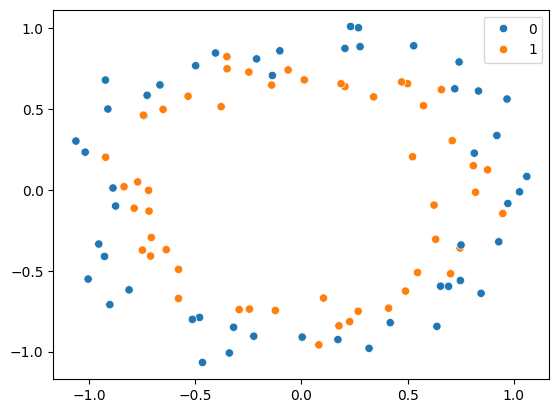

In [3]:
sns.scatterplot(x=x[:,0],y=x[:,1],hue=y)

In [4]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [5]:
model=Sequential()

In [6]:
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [8]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=1000,verbose=0)

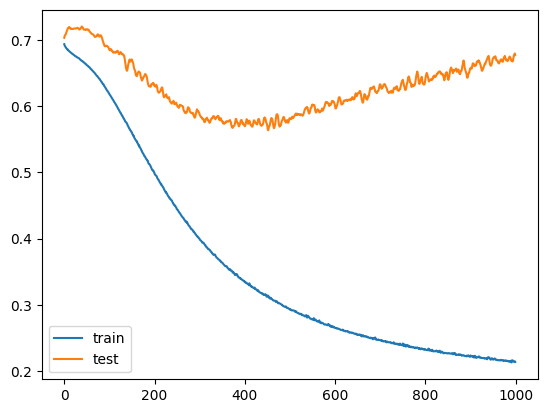

In [9]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"],label='train')
plt.plot(history.history["val_loss"],label='test')
plt.legend()
plt.show()

In [10]:

from mlxtend.plotting import plot_decision_regions

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step


<Axes: >

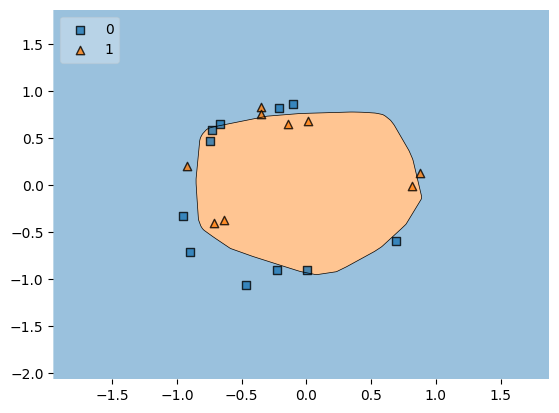

In [11]:
plot_decision_regions(x_test,y_test.ravel(),clf=model,legend=2)

In [23]:
model=Sequential()
model.add(Dense(256,input_dim=2,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])


In [61]:
callback=EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=100,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True
)

In [62]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=2000,callbacks=callback,verbose=0)

Epoch 101: early stopping
Restoring model weights from the end of the best epoch: 1.


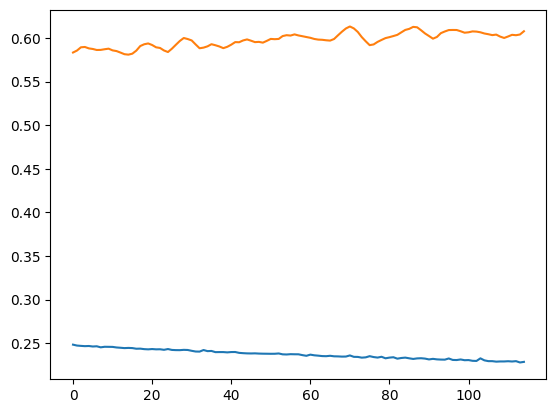

In [58]:
plt.plot(history.history["loss"],label='train')
plt.plot(history.history['val_loss'],label='test')
plt.show()